<a href="https://colab.research.google.com/github/oliviahfrank/hello/blob/main/coding_homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Olivia Frank
*Intro to neural data analysis*

**April 3**

In [2]:
#Importing all the programs I will need for the assignment!
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url1= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
url2= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
url3= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
url4= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'
# defining the urls to use so I can use all the information from the CSV files
# used a delimiter to get rid of any empty spaces in the data

spikes_left_trial1 = np.loadtxt(url1, delimiter = ',')
spikes_right_trial1 = np.loadtxt(url2, delimiter = ',')
spikes_left_trial2 = np.loadtxt(url3, delimiter = ',')
spikes_right_trial2 = np.loadtxt(url4, delimiter = ',')

In [4]:
print('Left 1:', len(spikes_left_trial1))
print('Left 2:', len(spikes_left_trial2))
print('Right 1:', len(spikes_right_trial1))
print('Right 2:', len(spikes_right_trial2))
#printed the length of each data set so that I can use that information later

Left 1: 65
Left 2: 53
Right 1: 45
Right 2: 69


In [5]:
print('Left 1:', len(spikes_left_trial1)/30)
print('Left 2:', len(spikes_left_trial2)/30)
print('Right 1:', len(spikes_right_trial1)/30)
print('Right 2:', len(spikes_right_trial2)/30)
#found the firing rate of each by looking at the lenth (number of spikes) per 30 seconds to see spikes per second

Left 1: 2.1666666666666665
Left 2: 1.7666666666666666
Right 1: 1.5
Right 2: 2.3


The neurons fire more in the first trial for the left, but more in the second trial for the right. The interval between the higher firing rate trial and lower firing rate trial is nearly the same, however there is no clear pattern from these data.

Text(0.5, 1.0, 'Right Trials')

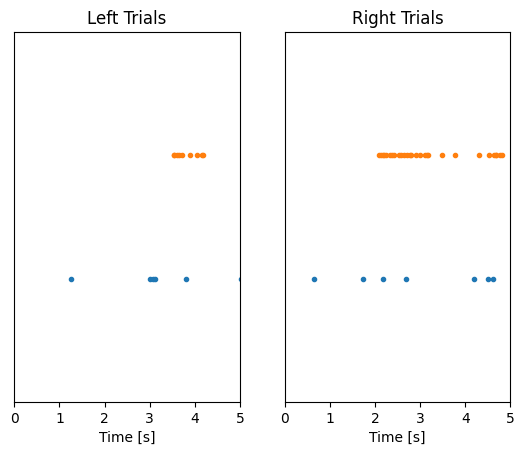

In [6]:
fig, ax = plt.subplots(1, 2)
#making a axis to put my sublots on

ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.')
ax[0].plot(spikes_left_trial2, 2 * np.ones_like(spikes_left_trial2), '.')
# plotting the spikes as two rows with one above the other for the left trials on one plot

ax[1].plot(spikes_right_trial1, np.ones_like(spikes_right_trial1), '.')
ax[1].plot(spikes_right_trial2, 2 * np.ones_like(spikes_right_trial2), '.')
# plotting the spikes as two rows with one above the other for the right trials on one plot



ax[0].set_xlim([0, 5])              # Display times 0 to 5 s on the x-axis
ax[0].set_ylim([0, 3])              # and set the y-axis limits
ax[0].set_xlabel('Time [s]')            #label the x-axis
ax[0].set_yticks([])                #remove y-axis ticks
ax[0].set_title('Left Trials')

ax[1].set_xlim([0, 5])              # Display times 0 to 5 s on the x-axis
ax[1].set_ylim([0, 3])              # and set the y-axis limits
ax[1].set_xlabel('Time [s]')            # label the x-axis
ax[1].set_yticks([])                #remove y-axis ticks
ax[1].set_title('Right Trials')


The second trial, the like higher up and that is orange, seems to be more bursty for both the left and right trails. The first trial is more evenly spaced out like a metronome.

In [7]:
# Compute ISIs and define them as variables to be used later
ISIsLeft1 = np.diff(spikes_left_trial1)
ISIsLeft2 = np.diff(spikes_left_trial2)
ISIsRight1 = np.diff(spikes_right_trial1)
ISIsRight2 = np.diff(spikes_right_trial2)

Text(0.5, 1.0, 'Right2')

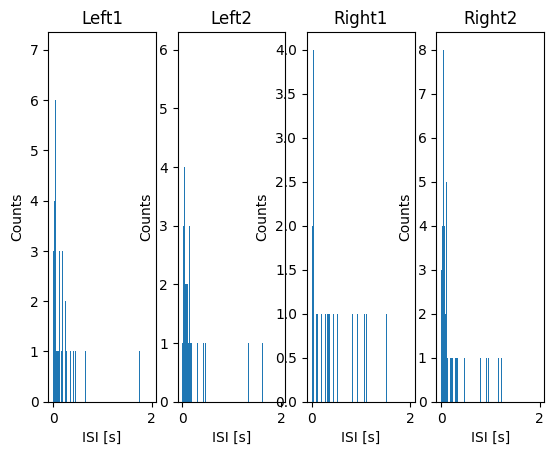

In [8]:
bins = np.arange(0, 2, 0.01)  # Define the bins for the histogram for 0-2 seconds with a bin size of 0.01

fig, ax = plt.subplots(1, 4)
#make the axis for my histograms to go into

#plotting the histograms in the bins of the ISI data
ax[0].hist(ISIsLeft1, bins)
ax[0].set_xlabel('ISI [s]')
ax[0].set_ylabel('Counts')
ax[0].set_title('Left1')

ax[1].hist(ISIsLeft2, bins)
ax[1].set_xlabel('ISI [s]')
ax[1].set_ylabel('Counts')
ax[1].set_title('Left2')

ax[2].hist(ISIsRight1, bins)
ax[2].set_xlabel('ISI [s]')
ax[2].set_ylabel('Counts')
ax[2].set_title('Right1')

ax[3].hist(ISIsRight2, bins)
ax[3].set_xlabel('ISI [s]')
ax[3].set_ylabel('Counts')
ax[3].set_title('Right2')

It does seem like trial 2 is more bursty, which is consistant with the graphs made earlier in the homework. They are more concentrated in the smaller bins meaning the spikes are closer together for the Left and Right second trials. The first trials for both left and right are more evenly spaced out like a metronome.

Text(0.5, 1.0, 'Trial 2')

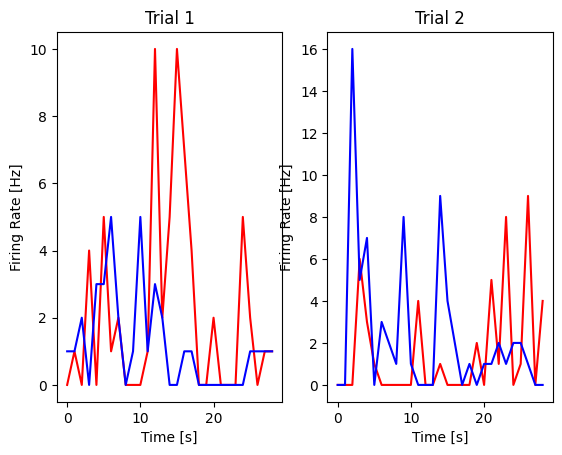

In [9]:
#defining bins for all of the different trials by making 1 second bins
# making time bins for 0-30 seconds in 1 second increments
# initializing the firing rate array
#looping through each bin, and then finding time stamps in each bin and isolate the true value in the boolean.
#I did this for each of the 4 variables (right and left trials 1 and 2)

binsize = 1                                                                   # Let's start with 1-second bins
fr_bins1 = np.arange(0,30,binsize)                                             # Make time bins (in 1 second increments) from 0 to 30 s
fr_left1 = np.zeros(len(fr_bins1)-1)                                             # Initialize our firing rate array
for i in range(len(fr_bins1)-1):                                               # Loop through each bin
  spk_left1 = (spikes_left_trial1 > fr_bins1[i]) & (spikes_left_trial1 < fr_bins1[i+1])           # Find timestamp values falling within each bin
  true_values = spikes_left_trial1[spk_left1]                                          # Our index is a boolean, so we need to isolate "True" values
  fr_left1[i] = (len(true_values))/binsize

binsize = 1                                                                   # Let's start with 1-second bins
fr_bins1 = np.arange(0,30,binsize)                                             # Make time bins (in 1 second increments) from 0 to 30 s
fr_right1 = np.zeros(len(fr_bins1)-1)                                             # Initialize our firing rate array
for i in range(len(fr_bins1)-1):                                               # Loop through each bin
  spk_right1 = (spikes_right_trial1 > fr_bins1[i]) & (spikes_right_trial1 < fr_bins1[i+1])           # Find timestamp values falling within each bin
  true_values = spikes_right_trial1[spk_right1]                                          # Our index is a boolean, so we need to isolate "True" values
  fr_right1[i] = (len(true_values))/binsize

binsize = 1                                                                   # Let's start with 1-second bins
fr_bins = np.arange(0,30,binsize)                                             # Make time bins (in 1 second increments) from 0 to 30 s
fr_left2 = np.zeros(len(fr_bins)-1)                                             # Initialize our firing rate array
for i in range(len(fr_bins)-1):                                               # Loop through each bin
  spk_left2 = (spikes_left_trial2 > fr_bins[i]) & (spikes_left_trial2 < fr_bins[i+1])           # Find timestamp values falling within each bin
  true_values = spikes_left_trial2[spk_left2]                                          # Our index is a boolean, so we need to isolate "True" values
  fr_left2[i] = (len(true_values))/binsize

binsize = 1                                                                   # Let's start with 1-second bins
fr_bins = np.arange(0,30,binsize)                                             # Make time bins (in 1 second increments) from 0 to 30 s
fr_right2 = np.zeros(len(fr_bins)-1)                                             # Initialize our firing rate array
for i in range(len(fr_bins)-1):                                               # Loop through each bin
  spk_right2 = (spikes_right_trial2 > fr_bins[i]) & (spikes_right_trial2 < fr_bins[i+1])           # Find timestamp values falling within each bin
  true_values = spikes_right_trial2[spk_right2]                                          # Our index is a boolean, so we need to isolate "True" values
  fr_right2[i] = (len(true_values))/binsize


fig, ax = plt.subplots(1, 2)
#making a axis to put our two subplots

#making a line plot for trial 1 and labling axes
ax[0].plot(fr_bins1[:-1], fr_left1, color='red')
ax[0].plot(fr_bins1[:-1], fr_right1, color='blue')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Firing Rate [Hz]')
ax[0].set_title('Trial 1')

#making a line plot for trial 2 and labling axes
ax[1].plot(fr_bins[:-1], fr_left2, color='red')
ax[1].plot(fr_bins[:-1], fr_right2, color='blue')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Firing Rate [Hz]')
ax[1].set_title('Trial 2')


On the first trial, the right spikes higher which means that it has a higher frequency oat around 10-15 seconds. The second trial had a higher frequency in the first 5-10 seconds on the left side. This means that the right side had a higher frequency around halfway through the 30 seconds and the left side had a higher frequency during the first bit of the 30 second window.